In [8]:
import numpy as np
import math
import matplotlib.pyplot as plt


*Gradient*

In [9]:
def f(x):
    return 3*x**2 - 4*x +5

In [11]:
f(3)

20

In [14]:
xs = np.arange(-5,5,0.25)
ys =f(xs)

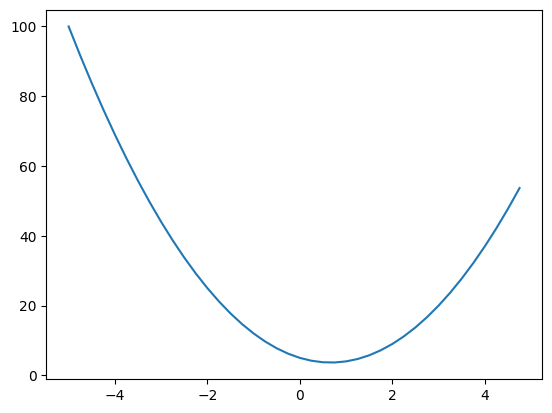

In [16]:
plt.plot(xs,ys)
plt.show()

In [22]:
h=0.00001
x=2/3
(f(x+h) -f(x))/h

3.0000002482211127e-05

In [24]:
a=2
b=-3
c=10
d=a*b+c
print(d)

4


In [ ]:
h=0.00001

In [25]:

d1=a*b+c
a+=h
d2=a*b+c

In [26]:
print(d1)
print(d2)
print("slpoe:",(d2-d1)/h)

4
3.9999699999999994
slpoe: -3.000000000064062


In [136]:
class value:
    def __init__ (self,data,_children=(),_op='',label=''):
        self.data=data
        self.grad =0.0
        self._backward = lambda: None
        self._prev =set(_children)
        self._op =_op
        self.label=label
        
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        other = other if isinstance(other,value) else value(other)
        out = value(self.data+other.data,(self,other),"+")
        
        def _backward():
            self.grad +=1.0* out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
        
    def __radd__(self, other): # other + self
        return self + other
        
    def __mul__(self,other):        
        other = other if isinstance(other,value) else value(other)
        out = value(self.data*other.data,(self,other),"*")
        def _backward():
            self.grad += other.data *out.grad
            other.grad += self.data*out.grad
        out._backward=_backward
        return out
    def __rmul__(self,other):
        return self*other
    def __pow__(self,other):
        assert isinstance (other,(int,float))
        out = value(self.data**other,(self, ),f"**{other}")

        def _backward():
            self.grad += (other * self.data**(other-1))*out.grad
        out._backward =_backward
        return out

    def __truediv__(self,other):
        return self * other**-1
        
    def __neg__(self):
        return self*-1
    def __sub__(self,other):
        return self + (-other)

    def tanh(self):
        x= self.data
        t =(math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = value(t,(self, ),'tanh')

        def _backward():
            self.grad += (1-t**2)*out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = value(math.exp(x),(self, ),'exp')

        def _backward():
            self.grad+=out.data*out.grad
        out._backward = _backward

        
    def backward(self):
        topo = []
        visited=set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad=1.0
        for node in reversed(topo):
            node._backward()
        

In [168]:
import random
class neuron:
    def __init__(self,nin):
        self.w=[value(random.uniform(-1,1)) for _ in range (nin)]
        self.b = value(random.uniform(-1,1))
        
    def __call__(self,x):
        #w*x + b
        act  = sum((wi*xi for wi,xi in zip(self.w,x)),self.b)
        out = act.tanh()
        return out
    def parameters(self):
        return self.w + [self.b]
        

class layer:
    def __init__(self,nin,nout):
        self.neurons =[neuron(nin) for _ in range (nout)]

    def __call__(self,x):
        outs =[n(x) for n in self.neurons]
        return outs[0] if len(outs) ==1 else outs
    def parameters(self):
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps)
        return params

class mlp:
    def __init__(self,nin,nouts):
        sz =[nin]+nouts
        self.layers = [layer(sz[i],sz[i+1]) for i in range (len(nouts))]
    def __call__(self,x):
        for layer in self.layers:
            x =layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    
        

y =[2.0,3.0,-1.0]
n=mlp(3,[4,4,1])
n(y)
            

Value(data=-0.6936871676379556)

In [169]:
n.parameters()

[Value(data=0.11054196748092249),
 Value(data=0.028065208828316424),
 Value(data=0.7222373971924214),
 Value(data=-0.8725872320263965),
 Value(data=-0.5939960891750908),
 Value(data=-0.9620082146065236),
 Value(data=0.4883879995847167),
 Value(data=-0.5130244304158897),
 Value(data=0.3519534709469585),
 Value(data=0.6694263309449839),
 Value(data=-0.3982587205108321),
 Value(data=0.4276159386773206),
 Value(data=0.5852050064924945),
 Value(data=0.1381031326282478),
 Value(data=-0.485904542848842),
 Value(data=-0.540382607361928),
 Value(data=0.10936536366597993),
 Value(data=0.6858792134428555),
 Value(data=-0.30734777456662865),
 Value(data=0.705617151021589),
 Value(data=0.754113153311208),
 Value(data=-0.9173018811587585),
 Value(data=-0.6869008639950025),
 Value(data=-0.804079678796588),
 Value(data=-0.6701952264934505),
 Value(data=-0.7213592199253278),
 Value(data=-0.13764250257242217),
 Value(data=-0.5111640394130879),
 Value(data=-0.8966383104037736),
 Value(data=0.855702568399

In [171]:
xs=[
    [2.0,3,0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0],
]
ys =[1.0,-1.0,-1.0,1.0]

for k in range (100):

    #forward pass
    ypred =[n(x) for x in xs]
    loss =sum((yout-ygt)**2 for ygt, yout in zip(ys,ypred))

    #backward pass
    for p in n.parameters():
        p.grad=0.0
    loss.backward()

    #update
    for p in n.parameters():
        p.data+= -0.01*p.grad
    print(k,loss.data)



0 6.10309405521687
1 5.509334722578534
2 4.783751485618368
3 4.003165527576563
4 3.298292319388109
5 2.751625913546903
6 2.3446020130323486
7 2.0214828358501804
8 1.7531922700679878
9 1.5298227460755174
10 1.344754469234252
11 1.1911797268893418
12 1.0627662888811014
13 0.9543049763047823
14 0.8617781263401699
15 0.7821465551426663
16 0.7130970500435172
17 0.652838839964868
18 0.5999589614409198
19 0.5533232856109739
20 0.5120085723947797
21 0.4752547749408715
22 0.44243057729381974
23 0.41300777204615813
24 0.3865417295833876
25 0.3626562052182895
26 0.3410313305088039
27 0.32139400295864773
28 0.30351012024281093
29 0.28717825637032984
30 0.2722244794498572
31 0.25849808225719034
32 0.24586804840204868
33 0.2342201150821649
34 0.22345432227650552
35 0.21348296040665993
36 0.20422884575578348
37 0.19562386650383656
38 0.1876077529906347
39 0.180127034393964
40 0.17313415088597822
41 0.1665866958693698
42 0.16044676737351388
43 0.1546804113258444
44 0.14925714237392523
45 0.14414953035

In [167]:
ypred

[Value(data=0.999999999999968),
 Value(data=-0.9999909518581843),
 Value(data=-0.9999999950460765),
 Value(data=1.0)]